In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS
from neuralforecast.losses.pytorch import MAE
from neuralforecast.tsdataset import TimeSeriesDataModule
from IPython.display import Image


# Model architecture

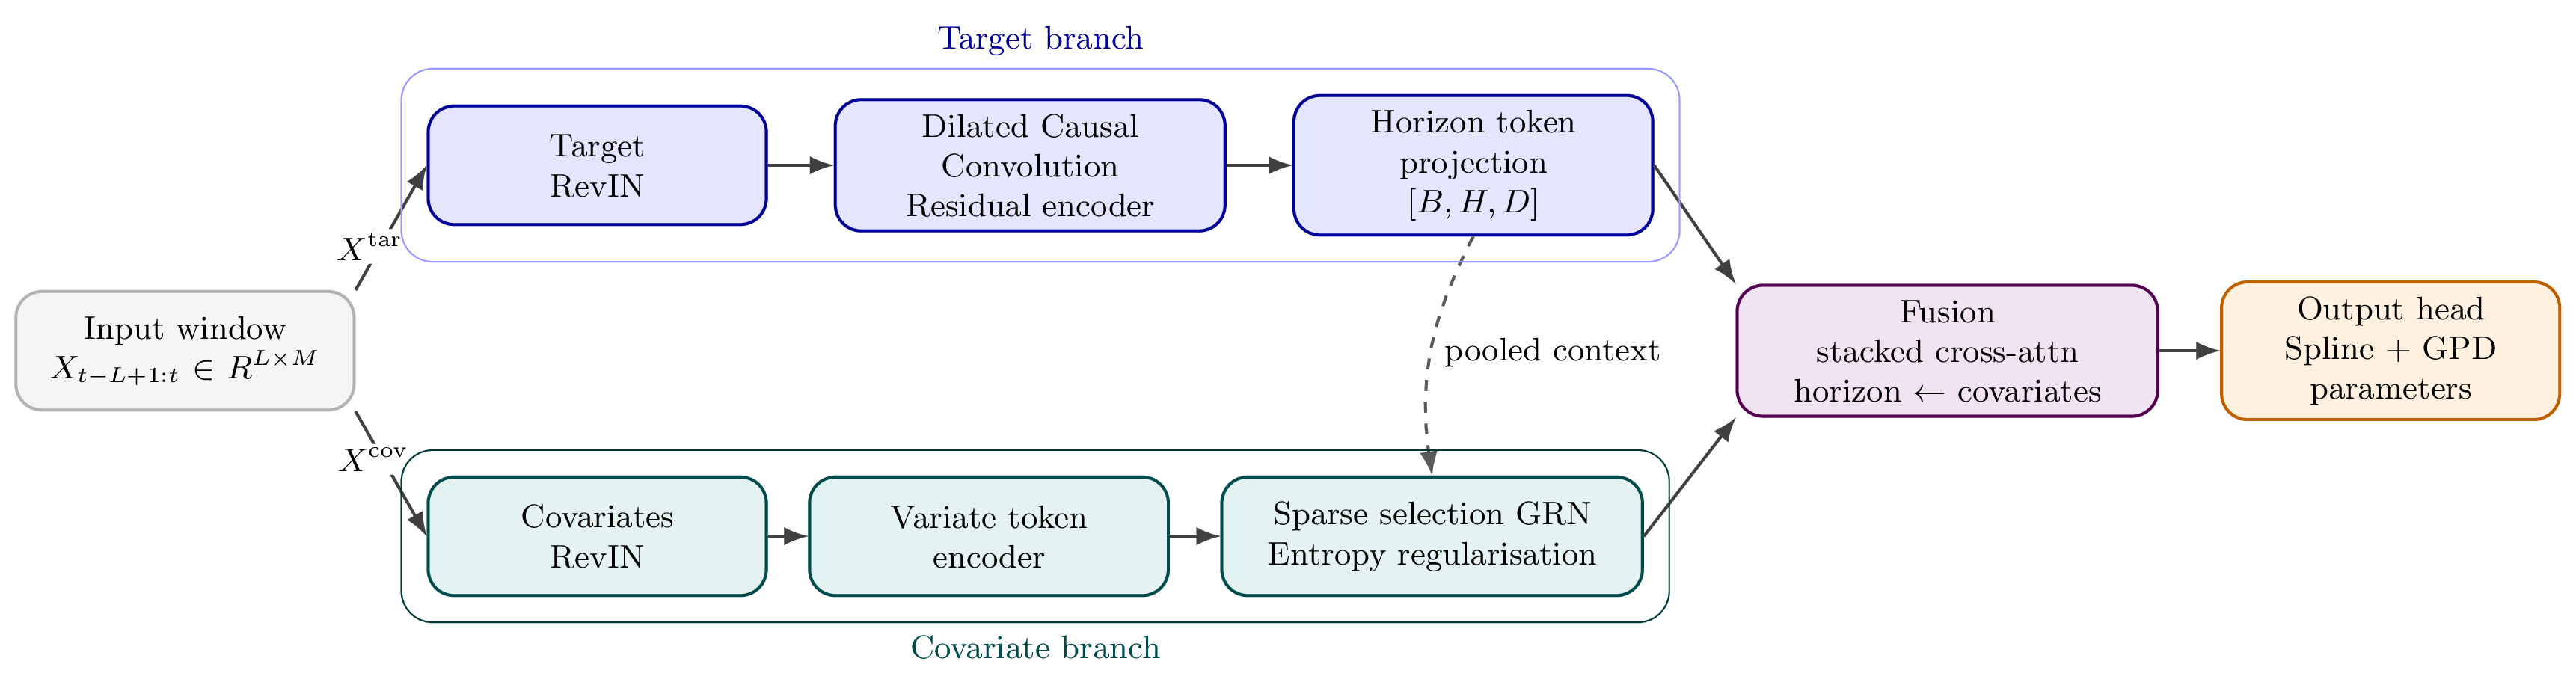

In [2]:
Image(filename="architecture_ML.png")

Saved figure to: stacked_dilated_residual_blocks.png


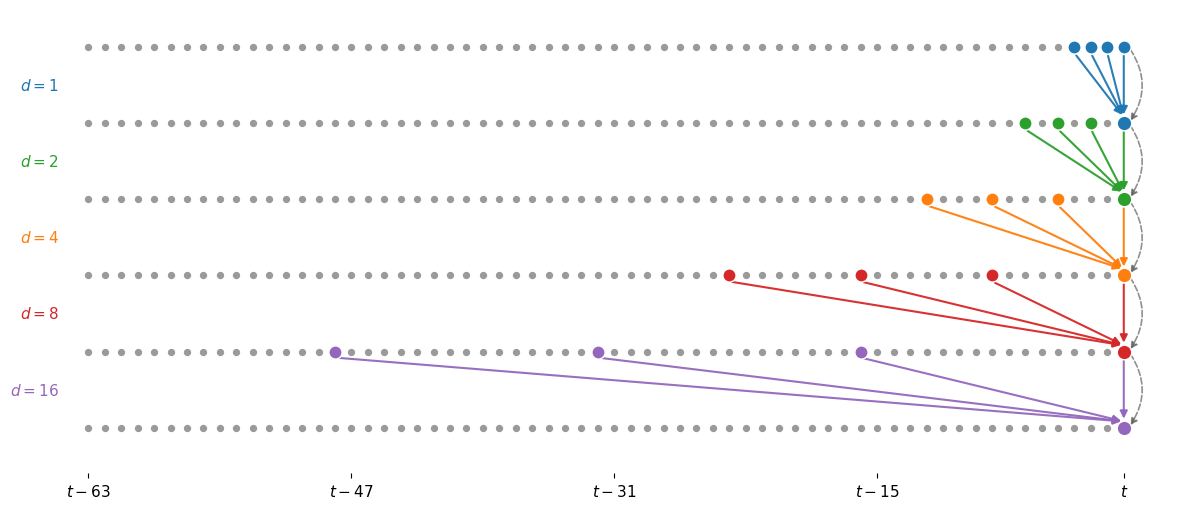

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch


def add_arrow(ax, start, end, color="black", lw=1.5, alpha=1.0,
              mutation_scale=12, rad=0.0, linestyle="-"):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=mutation_scale,
        linewidth=lw,
        color=color,
        alpha=alpha,
        linestyle=linestyle,
        connectionstyle=f"arc3,rad={rad}"
    )
    ax.add_patch(arrow)
    return arrow


def plot_stacked_dilated_residual_blocks(
    L=40,
    N=4,
    k=3,
    savepath="stacked_dilated_residual_blocks.png",
    dpi=300,
    show_skip=True,
    show_dilation_labels=True,
):
    """
    Minimal visual guide for stacked residual dilated causal convolution blocks.

    Shows:
      - one row per representation U^(i)
      - dilated causal taps into the current time t
      - optional residual/skip path
      - no title and minimal text

    Parameters
    ----------
    L : int
        Number of visible lookback time steps.
    N : int
        Number of residual blocks.
    k : int
        Kernel size.
    savepath : str
        Output filename.
    dpi : int
        Save resolution.
    show_skip : bool
        Whether to show residual skip arrows.
    show_dilation_labels : bool
        Whether to show small d=1, d=2, ... labels.
    """

    fig, ax = plt.subplots(figsize=(12, 5.2))

    colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728", "#9467bd", "#8c564b"]

    t_current = L - 1
    y_rows = np.arange(N + 1)

    # ------------------------------------------------------------
    # Draw faint temporal nodes for each layer representation
    # ------------------------------------------------------------
    for y in y_rows:
        ax.scatter(
            np.arange(L),
            np.full(L, y),
            s=18,
            color="#9A9A9A",
            zorder=1
        )

    # ------------------------------------------------------------
    # Draw each residual block's dilated causal taps
    # ------------------------------------------------------------
    for i in range(N):
        d = 2 ** i
        color = colors[i % len(colors)]

        y_in = i
        y_out = i + 1

        taps = [t_current - m * d for m in range(k)]
        taps = [tap for tap in taps if tap >= 0]

        # Highlight causal taps on input row
        ax.scatter(
            taps,
            np.full(len(taps), y_in),
            s=90,
            color=color,
            edgecolor="white",
            linewidth=1.0,
            zorder=5
        )

        # Highlight output node at current time
        ax.scatter(
            [t_current],
            [y_out],
            s=110,
            color=color,
            edgecolor="white",
            linewidth=1.0,
            zorder=6
        )

        # Arrows from dilated taps to current output
        for tap in taps:
            add_arrow(
                ax,
                (tap, y_in + 0.08),
                (t_current, y_out - 0.08),
                color=color,
                lw=1.5,
                alpha=0.95,
                mutation_scale=11
            )

        # Optional residual skip connection
        if show_skip:
            add_arrow(
                ax,
                (t_current + 0.3, y_in),
                (t_current + 0.3, y_out),
                color="#555555",
                lw=1.2,
                alpha=0.65,
                mutation_scale=10,
                rad=-0.35,
                linestyle="--"
            )

        # Minimal dilation label
        if show_dilation_labels:
            ax.text(
                -1.8,
                y_in + 0.5,
                rf"$d={d}$",
                ha="right",
                va="center",
                fontsize=11,
                color=color
            )

    # ------------------------------------------------------------
    # Minimal time labels
    # ------------------------------------------------------------
    tick_positions = sorted(set([
        0,
        L // 4,
        L // 2,
        3 * L // 4,
        L - 1
    ]))

    def time_label(x):
        lag = L - 1 - x
        if lag == 0:
            return r"$t$"
        return rf"$t-{lag}$"

    ax.set_xticks(tick_positions)
    ax.set_xticklabels([time_label(x) for x in tick_positions], fontsize=11)

    # Remove all unnecessary visual elements
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xlim(-4, L + 2)
    ax.set_ylim(-0.5, N + 0.6)

    ax.invert_yaxis()

    plt.tight_layout()
    fig.savefig(savepath, dpi=dpi, bbox_inches="tight", transparent=True)
    print(f"Saved figure to: {savepath}")

    return fig, ax


if __name__ == "__main__":
    fig, ax = plot_stacked_dilated_residual_blocks(
        L=64,
        N=5,
        k=4,
        savepath="stacked_dilated_residual_blocks.png",
        show_skip=True,
        show_dilation_labels=True
    )

    plt.show()

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


def plot_selection_and_attention_heatmaps(
    selection_weights,
    attention_weights,
    covariate_names=None,
    horizon_labels=None,
    sample_labels=None,
    savepath="selection_attention_heatmaps.png",
    dpi=300,
    selection_cmap="Greens",
    attention_cmap="Blues",
    zero_threshold=1e-8,
    mask_zero_selection=True,
    show_values=True,
    figsize=(12, 5),
):
    """
    Plot interpretable diagnostics from the sparse covariate-selection module
    and target-covariate cross-attention fusion layer.

    Parameters
    ----------
    selection_weights : array-like
        Either shape [V] for one input window,
        or shape [B, V] for several input windows/samples.
        These are the sparse selection weights pi_v.

    attention_weights : array-like
        Shape [H, V] for one attention map,
        or shape [num_heads, H, V],
        or shape [num_layers, num_heads, H, V].
        The function averages over extra leading dimensions by default.

    covariate_names : list[str], optional
        Covariate names of length V.

    horizon_labels : list[str], optional
        Forecast horizon labels of length H.

    sample_labels : list[str], optional
        Row labels for selection heatmap if selection_weights has shape [B, V].

    savepath : str
        Output path.

    dpi : int
        Figure resolution.

    selection_cmap : str
        Matplotlib colormap for selection weights.

    attention_cmap : str
        Matplotlib colormap for attention.

    zero_threshold : float
        Values below this are treated as exact zero.

    mask_zero_selection : bool
        If True, attention columns corresponding to zero selected covariates
        are visually greyed out.

    show_values : bool
        Whether to annotate heatmap cells with numeric values.

    figsize : tuple
        Figure size.
    """

    # ------------------------------------------------------------
    # Prepare arrays
    # ------------------------------------------------------------
    selection_weights = np.asarray(selection_weights, dtype=float)
    attention_weights = np.asarray(attention_weights, dtype=float)

    # Selection can be [V] or [B, V]
    if selection_weights.ndim == 1:
        selection_matrix = selection_weights[None, :]
        single_selection = True
    elif selection_weights.ndim == 2:
        selection_matrix = selection_weights
        single_selection = False
    else:
        raise ValueError(
            "selection_weights must have shape [V] or [B, V]."
        )

    B, V = selection_matrix.shape

    # Attention can be [H, V], [heads, H, V], or [layers, heads, H, V]
    if attention_weights.ndim == 2:
        attention_matrix = attention_weights
    elif attention_weights.ndim == 3:
        # Average over heads
        attention_matrix = attention_weights.mean(axis=0)
    elif attention_weights.ndim == 4:
        # Average over layers and heads
        attention_matrix = attention_weights.mean(axis=(0, 1))
    else:
        raise ValueError(
            "attention_weights must have shape [H, V], [heads, H, V], "
            "or [layers, heads, H, V]."
        )

    H, V_attn = attention_matrix.shape
    if V_attn != V:
        raise ValueError(
            f"Number of covariates differs: selection has V={V}, "
            f"attention has V={V_attn}."
        )

    # Names
    if covariate_names is None:
        covariate_names = [f"x{j+1}" for j in range(V)]

    if horizon_labels is None:
        horizon_labels = [f"h{h+1}" for h in range(H)]

    if sample_labels is None:
        if single_selection:
            sample_labels = [r"$\pi$"]
        else:
            sample_labels = [f"sample {i+1}" for i in range(B)]

    # Identify selected / inactive covariates.
    # If multiple samples are provided, use average selection.
    avg_selection = selection_matrix.mean(axis=0)
    inactive = avg_selection <= zero_threshold

    # Optional visual masking for attention
    attention_to_plot = attention_matrix.copy()
    if mask_zero_selection:
        attention_to_plot[:, inactive] = np.nan

    # ------------------------------------------------------------
    # Figure setup
    # ------------------------------------------------------------
    fig, axes = plt.subplots(
        1, 2,
        figsize=figsize,
        gridspec_kw={"width_ratios": [1.0, 1.4]},
        constrained_layout=True
    )

    ax_sel, ax_attn = axes

    # ------------------------------------------------------------
    # Selection heatmap
    # ------------------------------------------------------------
    im_sel = ax_sel.imshow(
        selection_matrix,
        aspect="auto",
        cmap=selection_cmap,
        vmin=0,
        vmax=max(selection_matrix.max(), 1e-12)
    )

    ax_sel.set_xticks(np.arange(V))
    ax_sel.set_xticklabels(covariate_names, rotation=45, ha="right", fontsize=9)

    ax_sel.set_yticks(np.arange(B))
    ax_sel.set_yticklabels(sample_labels, fontsize=9)

    ax_sel.set_title("Selection weights", fontsize=11, pad=8)

    cbar_sel = fig.colorbar(im_sel, ax=ax_sel, fraction=0.046, pad=0.04)
    cbar_sel.ax.set_ylabel(r"$\pi_v$", rotation=90, fontsize=10)

    # Annotate values
    if show_values:
        for i in range(B):
            for j in range(V):
                val = selection_matrix[i, j]
                txt = "0" if val <= zero_threshold else f"{val:.2f}"
                color = "white" if val > 0.5 * selection_matrix.max() else "#222222"
                ax_sel.text(
                    j, i, txt,
                    ha="center", va="center",
                    fontsize=8,
                    color=color
                )

    # Grey out inactive columns
    for j in range(V):
        if inactive[j]:
            ax_sel.axvspan(j - 0.5, j + 0.5, color="lightgrey", alpha=0.35)

    # ------------------------------------------------------------
    # Attention heatmap
    # ------------------------------------------------------------
    # Copy base cmap and set NaN color to light grey
    base_cmap = plt.get_cmap(attention_cmap).copy()
    base_cmap.set_bad(color="#E0E0E0")

    im_attn = ax_attn.imshow(
        attention_to_plot,
        aspect="auto",
        cmap=base_cmap,
        vmin=0,
        vmax=np.nanmax(attention_to_plot)
        if np.isfinite(attention_to_plot).any()
        else 1.0
    )

    ax_attn.set_xticks(np.arange(V))
    ax_attn.set_xticklabels(covariate_names, rotation=45, ha="right", fontsize=9)

    ax_attn.set_yticks(np.arange(H))
    ax_attn.set_yticklabels(horizon_labels, fontsize=9)

    ax_attn.set_title("Cross-attention", fontsize=11, pad=8)

    cbar_attn = fig.colorbar(im_attn, ax=ax_attn, fraction=0.046, pad=0.04)
    cbar_attn.ax.set_ylabel(r"$A_{h,v}$", rotation=90, fontsize=10)

    # Annotate attention values
    if show_values:
        max_attn = np.nanmax(attention_to_plot) if np.isfinite(attention_to_plot).any() else 1.0
        for h in range(H):
            for j in range(V):
                val = attention_to_plot[h, j]
                if np.isnan(val):
                    txt = "—"
                    color = "#777777"
                else:
                    txt = "0" if val <= zero_threshold else f"{val:.2f}"
                    color = "white" if val > 0.5 * max_attn else "#222222"

                ax_attn.text(
                    j, h, txt,
                    ha="center", va="center",
                    fontsize=8,
                    color=color
                )

    # Grid lines for both heatmaps
    for ax in [ax_sel, ax_attn]:
        ax.set_xticks(np.arange(-0.5, V, 1), minor=True)
        ax.set_yticks(
            np.arange(-0.5, ax.get_images()[0].get_array().shape[0], 1),
            minor=True
        )
        ax.grid(which="minor", color="white", linestyle="-", linewidth=1.0)
        ax.tick_params(which="minor", bottom=False, left=False)

        for spine in ax.spines.values():
            spine.set_visible(False)

    fig.savefig(savepath, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure to: {savepath}")

    return fig, axes

Saved figure to: timexer_style_fusion_diagnostics.png


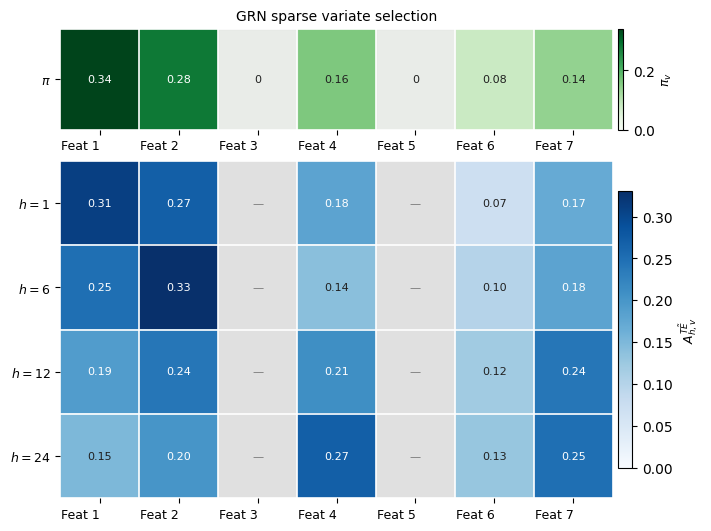

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


def _prepare_attention(attn):
    """
    Accepts:
      [H, V] or [H, H]
      [heads, H, V] or [heads, H, H]
      [layers, heads, H, V] or [layers, heads, H, H]

    Returns:
      matrix averaged over extra leading dimensions.
    """
    attn = np.asarray(attn, dtype=float)

    if attn.ndim == 2:
        return attn
    elif attn.ndim == 3:
        return attn.mean(axis=0)
    elif attn.ndim == 4:
        return attn.mean(axis=(0, 1))
    else:
        raise ValueError(
            "Attention must have shape [A,B], [heads,A,B], "
            "or [layers,heads,A,B]."
        )


def _annotate_heatmap(ax, data, threshold=None, fmt="{:.2f}", fontsize=8):
    """Add numeric annotations to heatmap."""
    arr = np.asarray(data)
    finite = arr[np.isfinite(arr)]

    if threshold is None:
        threshold = 0.5 * finite.max() if finite.size else 0.5

    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            val = arr[i, j]

            if np.isnan(val):
                txt = "—"
                color = "#777777"
            else:
                txt = "0" if abs(val) < 1e-10 else fmt.format(val)
                color = "white" if val > threshold else "#202020"

            ax.text(
                j, i, txt,
                ha="center",
                va="center",
                fontsize=fontsize,
                color=color
            )


def _style_matrix_axis(ax, xlabels, ylabels, xrot=45):
    """Shared minimal heatmap styling."""
    ax.set_xticks(np.arange(len(xlabels)))
    ax.set_xticklabels(xlabels, rotation=xrot, ha="right", fontsize=9)

    ax.set_yticks(np.arange(len(ylabels)))
    ax.set_yticklabels(ylabels, fontsize=9)

    ax.set_xticks(np.arange(-0.5, len(xlabels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(ylabels), 1), minor=True)

    ax.grid(which="minor", color="white", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    for spine in ax.spines.values():
        spine.set_visible(False)


def plot_timexer_style_fusion_diagnostics(
    selection_weights,
    cross_attention,
    target_self_attention=None,
    covariate_names=None,
    horizon_labels=None,
    savepath="timexer_style_fusion_diagnostics.png",
    dpi=300,
    zero_threshold=1e-8,
    mask_unselected=True,
    show_values=True,
    figsize=(13.5, 5.2),
    selection_cmap="Greens",
    self_cmap="Oranges",
    cross_cmap="Blues",
):
    """
    TimeXer-style diagnostic figure for your fusion module.

    Panels:
      1. Target-token strip
      2. GRN sparse variate selection heatmap: 1 x V
      3. Target-token self-attention heatmap: H x H
      4. Target-to-covariate cross-attention heatmap: H x V

    Intended correspondence:

      TimeXer:
        endogenous tokens      -> self-attention
        exogenous variate tokens -> cross-attention

      Your model:
        horizon target tokens T      -> self-attention
        selected covariate tokens E~ -> cross-attention
        GRN/sparsemax weights pi     -> selection diagnostic

    Parameters
    ----------
    selection_weights : array-like, shape [V]
        GRN sparse selection weights pi_v.

    cross_attention : array-like
        Cross-attention weights. Accepted shapes:
          [H, V]
          [heads, H, V]
          [layers, heads, H, V]
        Extra leading dimensions are averaged.

    target_self_attention : array-like, optional
        Target self-attention matrix. Accepted shapes:
          [H, H]
          [heads, H, H]
          [layers, heads, H, H]
        If None, a synthetic horizon-local self-attention matrix is generated.

    covariate_names : list[str], optional
        Exogenous variable / covariate token names.

    horizon_labels : list[str], optional
        Target horizon token labels.

    savepath : str
        Path for saving the figure.

    dpi : int
        Save resolution.

    zero_threshold : float
        Selection weights <= this value are treated as inactive/exact zero.

    mask_unselected : bool
        If True, cross-attention columns with pi_v = 0 are greyed out.

    show_values : bool
        If True, annotate heatmap cells with numeric values.

    figsize : tuple
        Figure size.

    selection_cmap, self_cmap, cross_cmap : str
        Matplotlib colormaps.
    """

    # ------------------------------------------------------------
    # Prepare selection and cross-attention
    # ------------------------------------------------------------
    pi = np.asarray(selection_weights, dtype=float)

    if pi.ndim != 1:
        raise ValueError("selection_weights must have shape [V].")

    if pi.sum() > 0:
        pi = pi / pi.sum()
    else:
        pi = np.ones_like(pi) / len(pi)

    cross = _prepare_attention(cross_attention)
    H, V = cross.shape

    if len(pi) != V:
        raise ValueError(
            f"selection_weights has length {len(pi)}, "
            f"but cross_attention has V={V}."
        )

    # ------------------------------------------------------------
    # Prepare target self-attention
    # ------------------------------------------------------------
    if target_self_attention is None:
        # Synthetic local self-attention across horizon tokens.
        idx = np.arange(H)
        dist = np.abs(idx[:, None] - idx[None, :])
        self_attn = np.exp(-0.7 * dist)
        self_attn = self_attn / self_attn.sum(axis=1, keepdims=True)
    else:
        self_attn = _prepare_attention(target_self_attention)

    if self_attn.shape != (H, H):
        raise ValueError(
            f"target_self_attention must resolve to shape [H,H] = [{H},{H}], "
            f"but got {self_attn.shape}."
        )

    # ------------------------------------------------------------
    # Labels
    # ------------------------------------------------------------
    if covariate_names is None:
        covariate_names = [rf"$z_{j+1}$" for j in range(V)]

    if horizon_labels is None:
        horizon_labels = [rf"$h_{i+1}$" for i in range(H)]

    inactive = pi <= zero_threshold

    cross_to_plot = cross.copy()
    if mask_unselected:
        cross_to_plot[:, inactive] = np.nan

    # ------------------------------------------------------------
    # Figure layout
    # ------------------------------------------------------------
    # fig = plt.figure(figsize=figsize, constrained_layout=True)

    # gs = fig.add_gridspec(
    #     2,
    #     3,
    #     height_ratios=[0.38, 1.0],
    #     width_ratios=[1.0, 0.75, 1.35],
    #     hspace=0.06,
    #     wspace=0.25
    # )

    # ax_target_strip = fig.add_subplot(gs[0, 0])
    # ax_selection = fig.add_subplot(gs[0, 1:])
    # ax_self = fig.add_subplot(gs[1, 0])
    # ax_cross = fig.add_subplot(gs[1, 1:])

    fig, (ax_selection, ax_cross) = plt.subplots(
        2, 1, figsize = figsize, gridspec_kw={"height_ratios": [0.3, 1]}, constrained_layout=True)

    # ------------------------------------------------------------
    # Top-right: GRN sparse selection weights
    # ------------------------------------------------------------
    sel_matrix = pi[None, :]

    im_sel = ax_selection.imshow(
        sel_matrix,
        aspect="auto",
        cmap=selection_cmap,
        vmin=0,
        vmax=max(pi.max(), 1e-12)
    )

    _style_matrix_axis(
        ax_selection,
        covariate_names,
        [r"$\pi$"],
        xrot=0
    )

    ax_selection.set_title("GRN sparse variate selection", fontsize=10, pad=6)

    if show_values:
        _annotate_heatmap(
            ax_selection,
            sel_matrix,
            threshold=0.5 * max(pi.max(), 1e-12),
            fontsize=8
        )

    # Grey inactive covariates
    for j in range(V):
        if inactive[j]:
            ax_selection.axvspan(
                j - 0.5,
                j + 0.5,
                color="#D9D9D9",
                alpha=0.45
            )

    cbar_sel = fig.colorbar(
        im_sel,
        ax=ax_selection,
        fraction=0.025,
        pad=0.01
    )
    cbar_sel.ax.set_ylabel(r"$\pi_v$", fontsize=9)


    # ------------------------------------------------------------
    # Bottom-right: target-to-covariate cross-attention
    # ------------------------------------------------------------
    cross_cmap_obj = plt.get_cmap(cross_cmap).copy()
    cross_cmap_obj.set_bad(color="#E0E0E0")

    vmax_cross = (
        np.nanmax(cross_to_plot)
        if np.isfinite(cross_to_plot).any()
        else 1.0
    )

    im_cross = ax_cross.imshow(
        cross_to_plot,
        aspect="auto",
        cmap=cross_cmap_obj,
        vmin=0,
        vmax=max(vmax_cross, 1e-12)
    )

    _style_matrix_axis(
        ax_cross,
        covariate_names,
        horizon_labels,
        xrot=0
    )

    # ax_cross.set_xlabel(
    #     r"key/value: selected exogenous variate token $\tilde{E}$",
    #     fontsize=9
    # )
    # ax_cross.set_ylabel(
    #     r"query: target token $T$",
    #     fontsize=9
    # )
    # ax_cross.set_title(
    #     r"target $\rightarrow$ covariate cross-attention $A^{T\tilde{E}}$",
    #     fontsize=10,
    #     pad=7
    # )

    if show_values:
        _annotate_heatmap(
            ax_cross,
            cross_to_plot,
            threshold=0.5 * max(vmax_cross, 1e-12),
            fontsize=8
        )

    cbar_cross = fig.colorbar(
        im_cross,
        ax=ax_cross,
        fraction=0.025,
        pad=0.01
    )
    cbar_cross.ax.set_ylabel(r"$A^{T\tilde{E}}_{h,v}$", fontsize=9)

    # ------------------------------------------------------------
    # Compact formula cue
    # ------------------------------------------------------------
    # fig.text(
    #     0.51,
    #     0.005,
    #     r"$\tilde e_v=\pi_v e_v,\quad "
    #     r"T'=T+\mathrm{MHSA}(T),\quad "
    #     r"T''=T'+\mathrm{MHCA}(Q=T',\,K,V=\tilde E)$",
    #     ha="center",
    #     va="bottom",
    #     fontsize=10
    # )

    fig.savefig(savepath, dpi=dpi, bbox_inches="tight", transparent = True)
    print(f"Saved figure to: {savepath}")

    return fig, (ax_selection, ax_cross)


# ---------------------------------------------------------------------
# Example usage
# ---------------------------------------------------------------------
if __name__ == "__main__":
    covariate_names = [
        "Feat 1",
        "Feat 2",
        "Feat 3",
        "Feat 4",
        "Feat 5",
        "Feat 6",
        "Feat 7"]

    horizon_labels = [
        r"$h=1$",
        r"$h=6$",
        r"$h=12$",
        r"$h=24$"
    ]

    # GRN sparsemax-like selection weights pi_v.
    # Some covariates are exactly zero.
    selection_weights = np.array([
        0.34,
        0.28,
        0.00,
        0.16,
        0.00,
        0.08,
        0.14
    ])

    # Cross-attention from target horizon tokens to selected covariate tokens.
    # Shape: [H, V]
    cross_attention = np.array([
        [0.31, 0.27, 0.00, 0.18, 0.00, 0.07, 0.17],
        [0.25, 0.33, 0.00, 0.14, 0.00, 0.10, 0.18],
        [0.19, 0.24, 0.00, 0.21, 0.00, 0.12, 0.24],
        [0.15, 0.20, 0.00, 0.27, 0.00, 0.13, 0.25],
    ])

    # Optional target self-attention.
    # If omitted, the function creates a synthetic horizon-local matrix.
    target_self_attention = np.array([
        [0.55, 0.25, 0.13, 0.07],
        [0.20, 0.45, 0.25, 0.10],
        [0.12, 0.25, 0.43, 0.20],
        [0.08, 0.15, 0.27, 0.50],
    ])

    fig, axes = plot_timexer_style_fusion_diagnostics(
        selection_weights=selection_weights,
        cross_attention=cross_attention,
        target_self_attention=target_self_attention,
        covariate_names=covariate_names,
        horizon_labels=horizon_labels,
        savepath="timexer_style_fusion_diagnostics.png",
        show_values=True,
        mask_unselected=True,
        figsize=(7, 5.2)
    )

    plt.show()

    # Cleaner slide version:
    # fig, axes = plot_timexer_style_fusion_diagnostics(
    #     selection_weights=selection_weights,
    #     cross_attention=cross_attention,
    #     target_self_attention=target_self_attention,
    #     covariate_names=covariate_names,
    #     horizon_labels=horizon_labels,
    #     savepath="timexer_style_fusion_diagnostics_clean.svg",
    #     show_values=False,
    #     mask_unselected=True,
    #     figsize=(13, 4.8)
    # )
    #
    # plt.show()

# NHITS Style Residual Encoder

Seed set to 29


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_steps=300` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Stack 1 residual identity max error: 0.000e+00
Stack 2 residual identity max error: 0.000e+00
Stack 3 residual identity max error: 0.000e+00


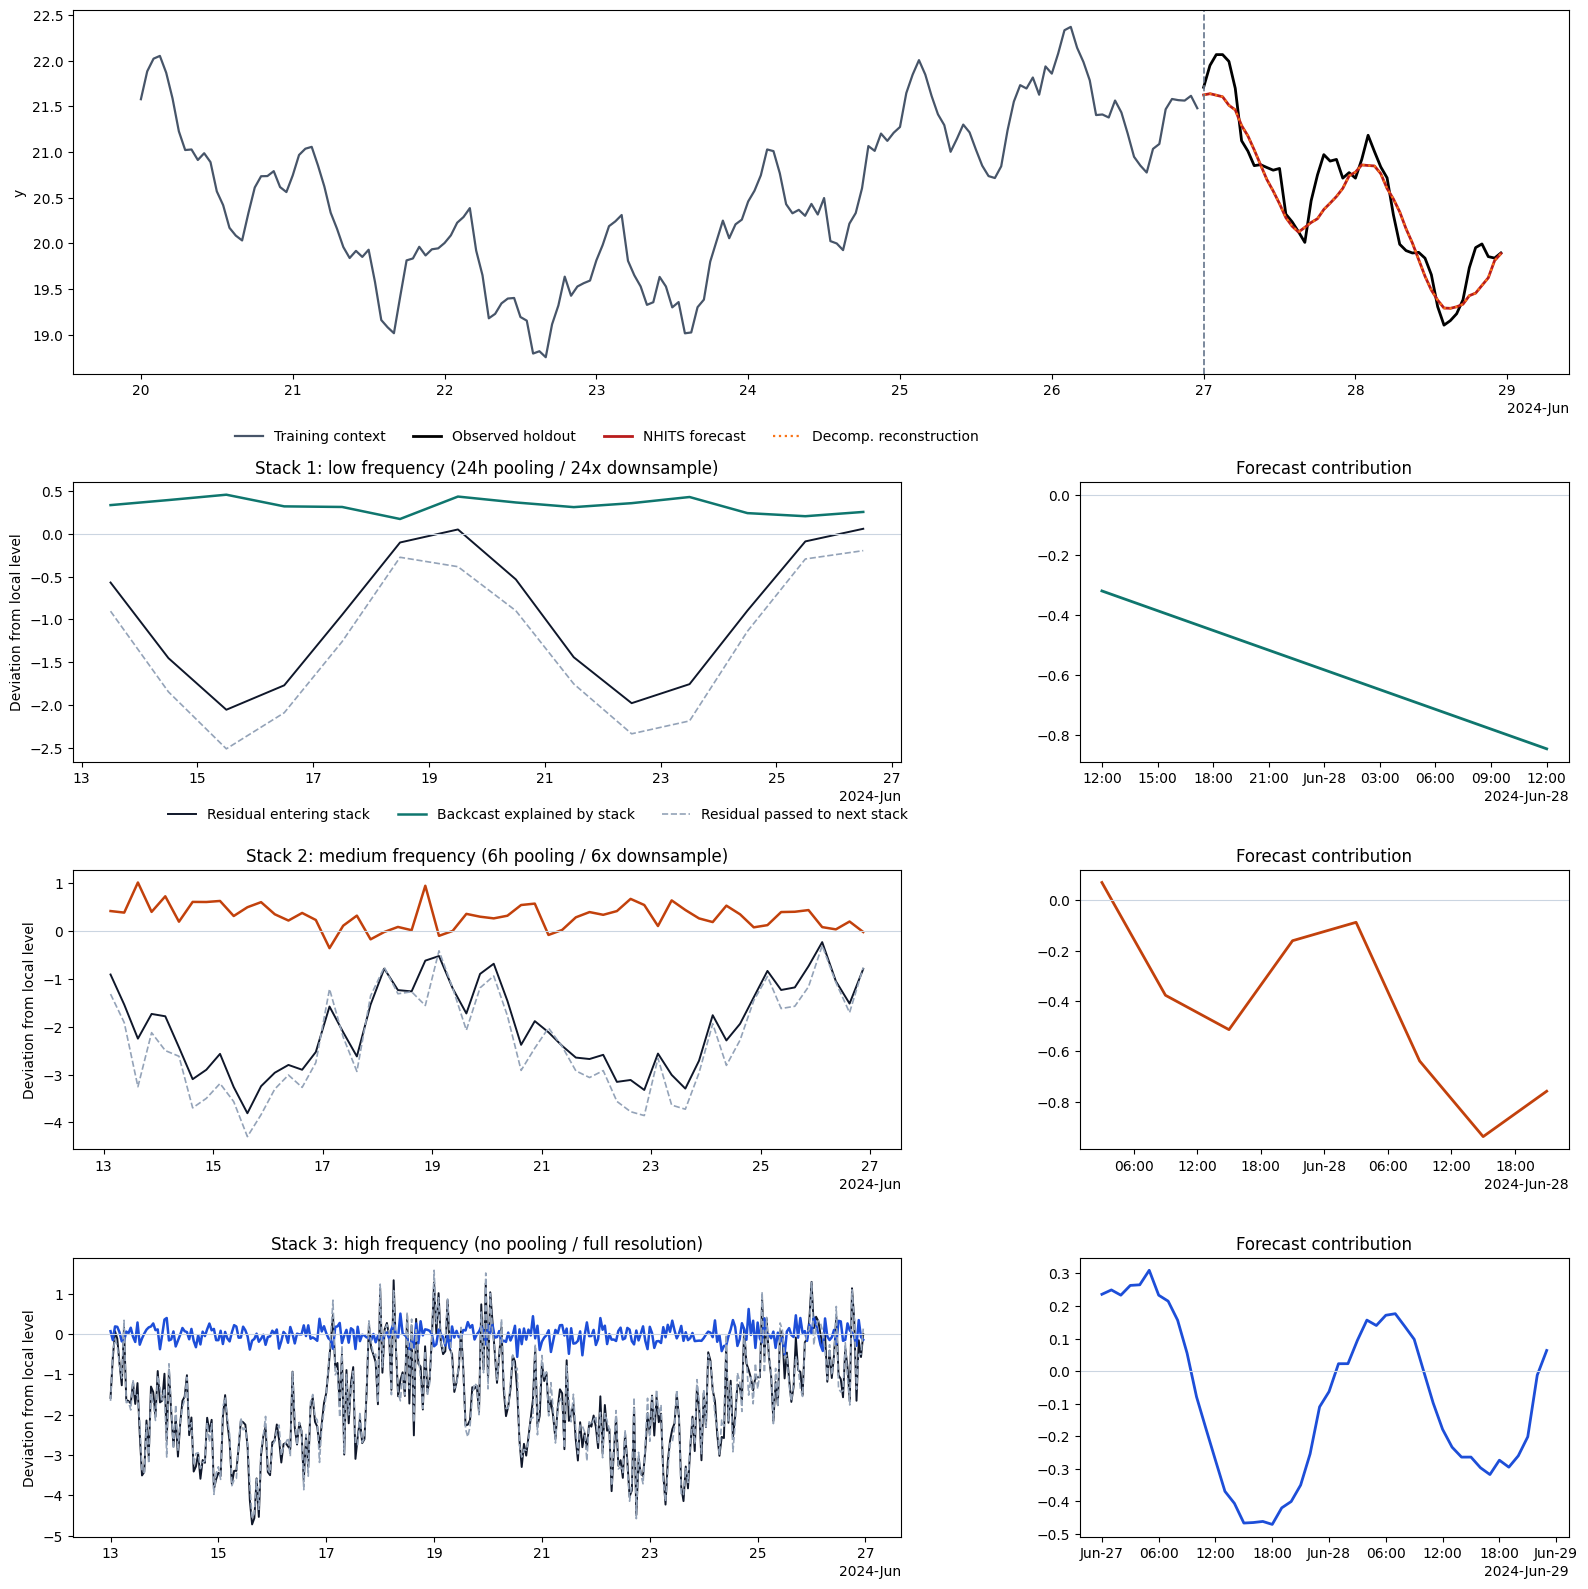

,ds,y,y_hat,abs_error
43,2024-06-28 19:00:00,19.952768,19.454235,0.498533
44,2024-06-28 20:00:00,19.992864,19.538561,0.454303
45,2024-06-28 21:00:00,19.853978,19.621803,0.232175
46,2024-06-28 22:00:00,19.838222,19.810858,0.027365
47,2024-06-28 23:00:00,19.894101,19.886988,0.007113


In [ ]:
h = 48
input_size = 24 * 14

def _apply_date_format(ax):
    loc = mdates.AutoDateLocator()
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))


def _as_int_kernel(k):
    if isinstance(k, tuple):
        return int(k[0])
    if isinstance(k, list):
        return int(k[0])
    return int(k)


def _pool_series(times, values, pool_k):
    """
    Average-pool a time series for display.
    Each pool window is represented by its midpoint timestamp.
    """
    pool_k = _as_int_kernel(pool_k)

    times = np.asarray(times)
    values = np.asarray(values, dtype=float)

    if pool_k <= 1 or len(values) < pool_k:
        return times, values

    n_pooled = len(values) // pool_k
    v = values[: n_pooled * pool_k].reshape(n_pooled, pool_k).mean(axis=1)
    t = times[: n_pooled * pool_k].reshape(n_pooled, pool_k)[:, pool_k // 2]
    return t, v


def _move_to_device(obj, device):
    if torch.is_tensor(obj):
        return obj.to(device)
    if isinstance(obj, dict):
        return {k: _move_to_device(v, device) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_move_to_device(v, device) for v in obj]
    if isinstance(obj, tuple):
        return tuple(_move_to_device(v, device) for v in obj)
    return obj

def make_synthetic_hourly_series(n_points=24 * 180, seed=21):
    rng = np.random.default_rng(seed)
    ds = pd.date_range("2024-01-01", periods=n_points, freq="h")
    t = np.arange(n_points)

    trend = 0.003 * t / 24
    weekly = 1.10 * np.sin(2 * np.pi * t / (24 * 7) - 0.4)
    daily = 0.55 * np.sin(2 * np.pi * t / 24 + 1.1)
    intraday = 0.25 * np.sin(2 * np.pi * t / 8 - 0.8)
    noise = 0.08 * rng.normal(size=n_points)

    y = 20 + trend + weekly + daily + intraday + noise

    return pd.DataFrame({
        "unique_id": "synthetic_pooltick",
        "ds": ds,
        "y": y,
        "trend": trend,
        "weekly": weekly,
        "daily": daily,
        "intraday": intraday,
        "noise": noise,
    })


def make_demo_nhits(
    h=48,
    input_size=24 * 14,
    max_steps=300,
    learning_rate=1e-3,
    random_seed=7,
):
    return NHITS(
        h=h,
        input_size=input_size,
        stack_types=["identity", "identity", "identity"],
        n_blocks=[1, 1, 1],
        mlp_units=[[128, 128], [128, 128], [128, 128]],
        n_pool_kernel_size=[24, 6, 1],
        n_freq_downsample=[24, 6, 1],
        pooling_mode="MaxPool1d",
        interpolation_mode="linear",
        activation="ReLU",
        loss=MAE(),
        scaler_type="identity",
        max_steps=max_steps,
        learning_rate=learning_rate,
        batch_size=32,
        windows_batch_size=256,
        inference_windows_batch_size=-1,
        early_stop_patience_steps=-1,
        val_check_steps=50,
        random_seed=random_seed,
        enable_progress_bar=False,
        enable_checkpointing=False,
        enable_model_summary=False,
        logger=False,
    )

def split_last_horizon(series_df, h, max_points=None):
    series = (
        series_df[["unique_id", "ds", "y"]]
        .copy()
        .sort_values(["unique_id", "ds"])
        .reset_index(drop=True)
    )
    series["ds"] = pd.to_datetime(series["ds"]).dt.tz_localize(None)

    if max_points is not None:
        series = (
            series.groupby("unique_id", group_keys=False, sort=False)
            .tail(max_points)
            .reset_index(drop=True)
        )

    train_parts, test_parts = [], []

    for _, group in series.groupby("unique_id", sort=False):
        if len(group) <= h:
            raise ValueError("Each series needs more than h observations.")
        train_parts.append(group.iloc[:-h])
        test_parts.append(group.iloc[-h:])

    return (
        pd.concat(train_parts, ignore_index=True),
        pd.concat(test_parts, ignore_index=True),
    )

def extract_nhits_stack_interpretation(nf):
    """
    Extract NHITS block-level residual inputs, backcasts, residual outputs,
    and forecast contributions for the final prediction window.

    Important orientation:
      - NHITS internally uses reversed insample residuals.
      - For plotting, arrays are flipped back to chronological order.
    """
    model = nf.models[0]
    model.eval()

    device = next(model.parameters()).device

    datamodule = TimeSeriesDataModule(dataset=nf.dataset, valid_batch_size=1)
    datamodule.setup(stage="predict")
    batch = next(iter(datamodule.predict_dataloader()))
    batch = _move_to_device(batch, device)

    # Select final prediction window
    windows_all = model._create_windows(batch, step="predict")
    last_window_idx = np.array([len(windows_all["temporal"]) - 1])

    windows = model._create_windows(batch, step="predict", w_idxs=last_window_idx)

    norm_out = model._normalization(windows=windows, y_idx=batch["y_idx"])
    if isinstance(norm_out, tuple):
        windows = norm_out[0]
    else:
        windows = norm_out

    insample_y, insample_mask, _, _, hist_exog, futr_exog, stat_exog = model._parse_windows(
        batch, windows
    )

    # Internal NHITS residual orientation
    residuals = insample_y.flip(dims=(-1,))
    insample_mask = insample_mask.flip(dims=(-1,))

    # NHITS level/naive component used in forecast reconstruction
    level = insample_y[:, -1:, None]
    level_component = (
        level.repeat(1, model.h, 1)
        .squeeze(0)
        .detach()
        .cpu()
        .numpy()
        .squeeze(-1)
    )

    residual_inputs = []
    backcasts = []
    residual_outputs = []
    stack_components = []

    with torch.no_grad():
        for block in model.blocks:
            # Store residual entering stack in chronological order
            residual_inputs.append(
                residuals.squeeze(0).detach().cpu().numpy()[::-1].copy()
            )

            backcast, block_forecast = block(
                insample_y=residuals,
                futr_exog=futr_exog,
                hist_exog=hist_exog,
                stat_exog=stat_exog,
            )

            # Store backcast in chronological order
            backcasts.append(
                backcast.squeeze(0).detach().cpu().numpy()[::-1].copy()
            )

            residuals = (residuals - backcast) * insample_mask

            # Store residual leaving stack in chronological order
            residual_outputs.append(
                residuals.squeeze(0).detach().cpu().numpy()[::-1].copy()
            )

            fc = block_forecast.squeeze(0).detach().cpu().numpy()
            fc = np.squeeze(fc)
            stack_components.append(fc.copy())

    stack_components = np.vstack(stack_components)
    total_forecast = level_component + stack_components.sum(axis=0)

    pool_kernel_sizes = []
    for block in model.blocks:
        if hasattr(block, "pooling_layer"):
            pool_kernel_sizes.append(_as_int_kernel(block.pooling_layer.kernel_size))
        else:
            pool_kernel_sizes.append(1)

    freq_downsample_sizes = list(model.hparams.get("n_freq_downsample", [1] * len(model.blocks)))
    freq_downsample_sizes = [_as_int_kernel(x) for x in freq_downsample_sizes]

    stack_labels = [
        "Stack 1: low frequency (24h pooling / 24x downsample)",
        "Stack 2: medium frequency (6h pooling / 6x downsample)",
        "Stack 3: high frequency (no pooling / full resolution)",
    ]

    # Sanity check: residual_in - backcast == residual_out
    for i in range(len(backcasts)):
        err = np.max(np.abs(residual_inputs[i] - backcasts[i] - residual_outputs[i]))
        print(f"Stack {i+1} residual identity max error: {err:.3e}")

    return {
        "context": insample_y.squeeze(0).detach().cpu().numpy().copy(),
        "level": level_component,
        "stack_components": stack_components,
        "forecast": total_forecast,
        "residual_inputs": residual_inputs,
        "backcasts": backcasts,
        "residual_outputs": residual_outputs,
        "stack_labels": stack_labels,
        "pool_kernel_sizes": pool_kernel_sizes,
        "freq_downsample_sizes": freq_downsample_sizes,
    }

def fit_nhits_demo(
    series_df,
    h=48,
    input_size=24 * 14,
    max_steps=300,
    max_points=None,
    random_seed=7,
):
    train_df, test_df = split_last_horizon(series_df, h=h, max_points=max_points)

    model = make_demo_nhits(
        h=h,
        input_size=input_size,
        max_steps=max_steps,
        random_seed=random_seed,
    )

    nf = NeuralForecast(models=[model], freq="h")
    nf.fit(df=train_df)

    forecast_df = nf.predict()

    if not {"unique_id", "ds"}.issubset(forecast_df.columns):
        forecast_df = forecast_df.reset_index()

    forecast_df = forecast_df.drop(columns=["index", "level_0"], errors="ignore")

    model_cols = [c for c in forecast_df.columns if c not in ["unique_id", "ds"]]
    model_col = model_cols[-1]

    forecast_df = (
        forecast_df[["unique_id", "ds", model_col]]
        .copy()
        .rename(columns={model_col: "y_hat"})
    )
    forecast_df["ds"] = pd.to_datetime(forecast_df["ds"])

    interpretation = extract_nhits_stack_interpretation(nf)

    return nf, train_df, test_df, forecast_df, interpretation
def plot_nhits_stack_decomposition_fixed(
    train_df,
    test_df,
    forecast_df,
    interpretation,
    title,
    context_points=24 * 7,
    save_path=None,
):
    n_stacks = len(interpretation["stack_labels"])
    colors = ["#0f766e", "#c2410c", "#1d4ed8"]

    pool_kernel_sizes = interpretation.get("pool_kernel_sizes", [1] * n_stacks)
    freq_downsample_sizes = interpretation.get("freq_downsample_sizes", [1] * n_stacks)

    context_df = train_df.tail(len(interpretation["context"])).copy()
    context_display = context_df.tail(min(context_points, len(context_df)))

    forecast_view = forecast_df[["ds", "y_hat"]].copy()
    forecast_view["ds"] = pd.to_datetime(forecast_view["ds"])
    forecast_ds = forecast_view["ds"].values

    fig = plt.figure(figsize=(16, 4 * (n_stacks + 1)))
    gs = fig.add_gridspec(
        n_stacks + 1,
        2,
        width_ratios=[2.2, 1.3],
        height_ratios=[1.3] + [1] * n_stacks,
    )
    ax_top = fig.add_subplot(gs[0, :])

    ax_top.plot(
        context_display["ds"],
        context_display["y"],
        color="#475569",
        lw=1.6,
        label="Training context",
    )
    ax_top.plot(
        test_df["ds"],
        test_df["y"],
        color="black",
        lw=2.0,
        label="Observed holdout",
    )
    ax_top.plot(
        forecast_view["ds"],
        forecast_view["y_hat"],
        color="#b91c1c",
        lw=2.0,
        label="NHITS forecast",
    )
    ax_top.plot(
        forecast_view["ds"],
        interpretation["forecast"],
        color="#f97316",
        lw=1.6,
        linestyle=":",
        label="Decomp. reconstruction",
    )

    ax_top.axvline(test_df["ds"].iloc[0], color="#64748b", lw=1.2, linestyle="--")
    # ax_top.set_title(title)
    ax_top.set_ylabel("y")
    ax_top.legend(bbox_to_anchor=(0.1, -0.12), ncols=4, loc="upper left", frameon=False)
    _apply_date_format(ax_top)

    for stack_idx, label in enumerate(interpretation["stack_labels"]):
        ax_left = fig.add_subplot(gs[stack_idx + 1, 0])
        ax_right = fig.add_subplot(gs[stack_idx + 1, 1])

        pool_k = pool_kernel_sizes[stack_idx]
        freq_ds = freq_downsample_sizes[stack_idx]

        residual_in_raw = np.asarray(interpretation["residual_inputs"][stack_idx], dtype=float)
        backcast_raw = np.asarray(interpretation["backcasts"][stack_idx], dtype=float)
        residual_out_raw = np.asarray(interpretation["residual_outputs"][stack_idx], dtype=float)

        # Local centering for visual readability
        local_level = float(residual_in_raw[-1])

        residual_in = residual_in_raw - local_level
        residual_out = residual_out_raw - local_level

        backcast_dev = backcast_raw

        context_times = context_df["ds"].values

        left_t, residual_in_p = _pool_series(context_times, residual_in, pool_k)
        _, backcast_p = _pool_series(context_times, backcast_dev, pool_k)
        _, residual_out_p = _pool_series(context_times, residual_out, pool_k)

        ax_left.plot(
            left_t,
            residual_in_p,
            color="#0f172a",
            lw=1.4,
            label="Residual entering stack",
        )
        ax_left.plot(
            left_t,
            backcast_p,
            color=colors[stack_idx],
            lw=1.8,
            label="Backcast explained by stack",
        )
        ax_left.plot(
            left_t,
            residual_out_p,
            color="#94a3b8",
            lw=1.2,
            linestyle="--",
            label="Residual passed to next stack",
        )

        ax_left.axhline(0.0, color="#cbd5e1", lw=0.8)
        ax_left.set_title(label)
        ax_left.set_ylabel("Deviation from local level")
        _apply_date_format(ax_left)

        # Forecast contribution
        fc_vals = np.asarray(interpretation["stack_components"][stack_idx], dtype=float)
        right_t, fc_vals_p = _pool_series(forecast_ds, fc_vals, freq_ds)

        ax_right.plot(right_t, fc_vals_p, color=colors[stack_idx], lw=2.0)
        ax_right.axhline(0.0, color="#cbd5e1", lw=0.8)
        ax_right.set_title("Forecast contribution")
        _apply_date_format(ax_right)

        if stack_idx == 0:
            ax_left.legend(bbox_to_anchor=(0.1, -0.12), ncols=3, loc="upper left", frameon=False)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, transparent=True, bbox_inches="tight")

    plt.show()

synthetic_df = make_synthetic_hourly_series(n_points=24 * 180, seed=21)

nf, synth_train_df, synth_test_df, synth_forecast_df, synth_interp = fit_nhits_demo(
    synthetic_df[["unique_id", "ds", "y"]],
    h=h,
    input_size=input_size,
    max_steps=300,
    max_points=None,
    random_seed=29,
)

plot_nhits_stack_decomposition_fixed(
    train_df=synth_train_df,
    test_df=synth_test_df,
    forecast_df=synth_forecast_df,
    interpretation=synth_interp,
    title="NHITS stack-wise residual decomposition on synthetic trend + multi-seasonality",
    context_points=24 * 7,
    save_path="nhits_stack_decomposition_fixed.png",
)

synth_results = synth_test_df.merge(
    synth_forecast_df,
    on=["unique_id", "ds"],
    how="left",
)

synth_results["abs_error"] = (synth_results["y"] - synth_results["y_hat"]).abs()
synth_results[["ds", "y", "y_hat", "abs_error"]].tail()

## L0 Regularization and Hard Concrete Distribution Gating

**L0 Regularization** encourages sparsity by penalizing the expected number of non-zero activations in a neural network. This helps with:
- Feature selection: identifying which inputs or hidden units are truly important
- Model compression: reducing parameters by zeroing out unnecessary connections
- Interpretability: understanding which features drive predictions

**Hard Concrete Distribution** is used for differentiable gating in L0-constrained neural networks. It's a sophisticated approach to enforce binary gating while maintaining differentiability:

1. **Bernoulli distribution**: Traditional discrete gating (z ∈ {0, 1}) - not differentiable for backprop
2. **Concrete distribution**: Continuous relaxation of Bernoulli on (0, 1) - differentiable but doesn't give hard 0/1 values
3. **Hard Concrete distribution**: Clipped stretch of Concrete with point masses at 0 and 1 - combines differentiability with hard gating at the boundaries

The hard concrete distribution parameters allow fine control over sparsity: the probability of gating (setting to 0), the continuous region, and full activation.

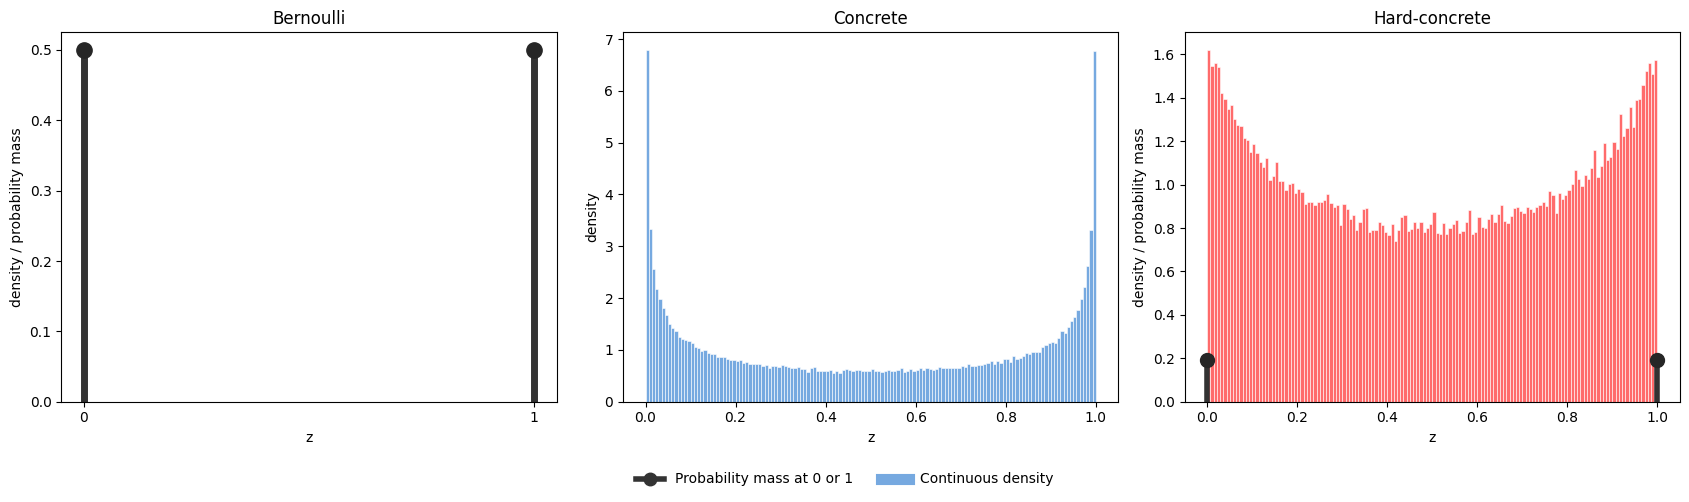

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


# Parameters for the distributions
loc = 0.0
tau = 0.6
gamma = -0.1
zeta = 1.1
n_samples = 200_000
rng = np.random.default_rng(7)

# Shared latent samples
u = rng.uniform(1e-6, 1 - 1e-6, size=n_samples)
logits = np.log(u) - np.log1p(-u)

# Bernoulli gate probability
pi = sigmoid(loc)

# Concrete samples in (0, 1)
concrete_samples = sigmoid((logits + loc) / tau)

# Hard-concrete samples after stretch and clipping
stretched_samples = concrete_samples * (zeta - gamma) + gamma
hard_concrete_samples = np.clip(stretched_samples, 0.0, 1.0)

# Exact boundary masses for hard concrete
left_boundary = sigmoid(tau * np.log(-gamma / zeta) - loc)
right_boundary = 1 - sigmoid(tau * np.log((1 - gamma) / (zeta - 1)) - loc)

# Interior samples only for the continuous density view
hard_interior = hard_concrete_samples[(hard_concrete_samples > 0) & (hard_concrete_samples < 1)]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- 1. Bernoulli ---
ax = axes[0]
bernoulli_x = np.array([0.0, 1.0])
bernoulli_mass = np.array([1 - pi, pi])
markerline, stemlines, baseline = ax.stem(bernoulli_x, bernoulli_mass, linefmt='0.25', markerfmt='o', basefmt=' ')
plt.setp(stemlines, linewidth=5, color='0.2')
plt.setp(markerline, markersize=11, markerfacecolor='0.15', markeredgecolor='0.15')
ax.set_title('Bernoulli')
ax.set_xlabel('z')
ax.set_ylabel('density / probability mass')
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(0, 1.05 * bernoulli_mass.max())
ax.set_xticks([0, 1])

# --- 2. Concrete ---
ax = axes[1]
ax.hist(
    concrete_samples,
    bins=140,
    range=(0, 1),
    density=True,
    color='#76a9e0',
    edgecolor='white',
    linewidth=0.4,
)
ax.set_title('Concrete')
ax.set_xlabel('z')
ax.set_ylabel('density')
ax.set_xlim(-0.05, 1.05)

# --- 3. Hard-concrete ---
ax = axes[2]
ax.hist(
    hard_interior,
    bins=140,
    range=(0, 1),
    density=True,
    color='#ff6b6b',
    edgecolor='white',
    linewidth=0.4,
)
markerline, stemlines, baseline = ax.stem([0.0, 1.0], [left_boundary, right_boundary], linefmt='0.25', markerfmt='o', basefmt=' ')
plt.setp(stemlines, linewidth=4, color='0.2')
plt.setp(markerline, markersize=10, markerfacecolor='0.15', markeredgecolor='0.15')
ax.set_title('Hard-concrete')
ax.set_xlabel('z')
ax.set_ylabel('density / probability mass')
ax.set_xlim(-0.05, 1.05)

legend_handles = [
    Line2D([0], [0], color='0.2', marker='o', linewidth=4, markersize=9, label='Probability mass at 0 or 1'),
    Line2D([0], [0], color='#76a9e0', linewidth=8, label='Continuous density'),
]
fig.legend(handles=legend_handles, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 0))

plt.tight_layout(rect=(0, 0, 1, 0.93))
plt.savefig('hard_concrete_plot.png', dpi=300, transparent=True, bbox_inches='tight')